# LEIE EDA

This script uses the raw LEIE_OIG_Exclusion_List.csv for exploratory data vizes.

In [1]:
# Packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import re

def to_snake_case(name: str) -> str:
    # Add underscore between lower-to-upper transitions
    name = re.sub(r'(.)([A-Z][a-z]+)', r'\1_\2', name)
    name = re.sub(r'([a-z0-9])([A-Z])', r'\1_\2', name)

    # Replace non-alphanumeric with underscores
    name = re.sub(r'[^0-9a-zA-Z]+', '_', name)

    # Remove leading/trailing underscores and lowercase
    return name.strip("_").lower()

In [3]:
df = pd.read_csv("/dsa/groups/casestudycf25/team02/bronze/LEIE_OIG_Exclusion_List.csv")

df = df.rename(columns={col: to_snake_case(col) for col in df.columns})

# Convert to datetime
df["excldate"] = pd.to_datetime(df["excldate"], format="%Y%m%d")

# Convert to datetime
df["npi"] = df["npi"].to_numpy(int)

df.head(5)

/tmp/ipykernel_1572/2074610176.py:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/dsa/groups/casestudycf25/team02/bronze/LEIE_OIG_Exclusion_List.csv")


,lastname,firstname,midname,busname,general,specialty,upin,npi,dob,address,city,state,zip,excltype,excldate,reindate,waiverdate,wvrstate
0,NaN,NaN,NaN,"#1 MARKETING SERVICE, INC",OTHER BUSINESS,SOBER HOME,NaN,0,NaN,239 BRIGHTON BEACH AVENUE,BROOKLYN,NY,11235,1128a1,2020-03-19,0,0,NaN
1,NaN,NaN,NaN,"1 BEST CARE, INC",OTHER BUSINESS,HOME HEALTH AGENCY,NaN,0,NaN,"2161 UNIVERSITY AVENUE W, STE",SAINT PAUL,MN,55114,1128b5,2023-05-18,0,0,NaN
2,NaN,NaN,NaN,101 FIRST CARE PHARMACY INC,OTHER BUSINESS,PHARMACY,NaN,1972902351,NaN,"C/O 609 W 191ST STREET, APT D",NEW YORK,NY,10040,1128b8,2022-03-20,0,0,NaN
3,NaN,NaN,NaN,14 LAWRENCE AVE PHARMACY,PHARMACY,NaN,NaN,0,NaN,14 LAWRENCE AVENUE,SMITHTOWN,NY,11787,1128a1,1988-08-30,0,0,NaN
4,NaN,NaN,NaN,143 MEDICAL EQUIPMENT CO,DME COMPANY,DME - OXYGEN,NaN,0,NaN,701 NW 36 AVENUE,MIAMI,FL,33125,1128b7,1997-06-20,0,0,NaN


In [4]:
df.shape

(81991, 18)

In [5]:
no_npis = df[df["npi"] > 0]

display(no_npis.head(4))

print(f"Total rows: {no_npis.shape[0]}")

,lastname,firstname,midname,busname,general,specialty,upin,npi,dob,address,city,state,zip,excltype,excldate,reindate,waiverdate,wvrstate
2,NaN,NaN,NaN,101 FIRST CARE PHARMACY INC,OTHER BUSINESS,PHARMACY,NaN,1972902351,NaN,"C/O 609 W 191ST STREET, APT D",NEW YORK,NY,10040,1128b8,2022-03-20,0,0,NaN
6,NaN,NaN,NaN,184TH STREET PHARMACY CORP,OTHER BUSINESS,PHARMACY,NaN,1922348218,NaN,69 E 184TH ST,BRONX,NY,10468,1128a1,2018-04-19,0,0,NaN
26,NaN,NaN,NaN,"A & Y MEDICAL SUPPLY, INC",DME COMPANY,DME - GENERAL,NaN,1942476080,NaN,"6310 108TH STREET, APT 6J",FOREST HILLS,NY,11375,1128b8,2017-05-18,0,0,NaN
30,NaN,NaN,NaN,"A CARING ALTERNATIVE, INC",OTHER BUSINESS,HOME HEALTH AGENCY,NaN,1275600959,NaN,"1229 HURON RD E, FLR 6TH",CLEVELAND,OH,44115,1128a1,2013-03-20,0,0,NaN


Total rows: 8263


In [6]:
no_npis[no_npis["excldate"] >= "2021-01-01"].shape

(3039, 18)

(array([2.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 2.000e+00, 3.000e+00,
        3.000e+00, 1.000e+00, 5.000e+00, 8.000e+00, 4.000e+00, 3.000e+00,
        5.000e+00, 4.000e+00, 1.100e+01, 1.300e+01, 1.840e+02, 3.770e+02,
        3.440e+02, 4.440e+02, 5.600e+02, 6.360e+02, 6.640e+02, 7.080e+02,
        5.680e+02, 5.250e+02, 5.090e+02, 8.030e+02, 8.450e+02, 1.031e+03]),
 array([ 6758.        ,  7211.03333333,  7664.06666667,  8117.1       ,
         8570.13333333,  9023.16666667,  9476.2       ,  9929.23333333,
        10382.26666667, 10835.3       , 11288.33333333, 11741.36666667,
        12194.4       , 12647.43333333, 13100.46666667, 13553.5       ,
        14006.53333333, 14459.56666667, 14912.6       , 15365.63333333,
        15818.66666667, 16271.7       , 16724.73333333, 17177.76666667,
        17630.8       , 18083.83333333, 18536.86666667, 18989.9       ,
        19442.93333333, 19895.96666667, 20349.        ]),
 <BarContainer object of 30 artists>)

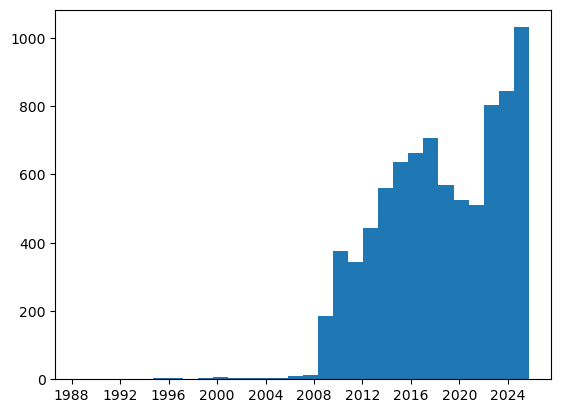

In [7]:
plt.hist(no_npis["excldate"], bins=30)

<BarContainer object of 10 artists>

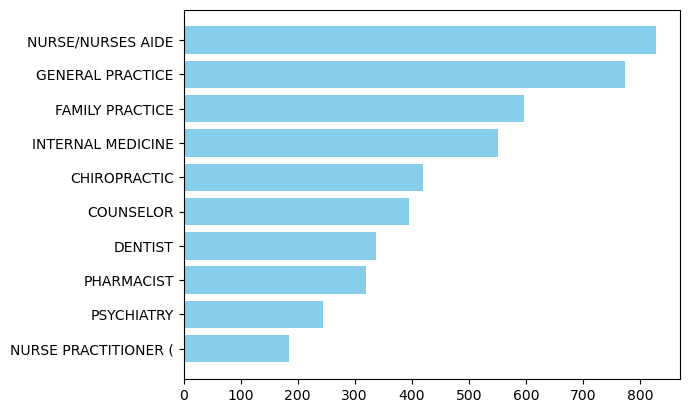

In [8]:
specialties = pd.DataFrame(no_npis["specialty"].value_counts())

specialties = specialties.head(10)

specialties = specialties.reset_index().rename(columns={"index": "specialty", "count": "count"}).sort_values(by="count", ascending=True)

plt.barh(specialties["specialty"], specialties["count"], color='skyblue')

<BarContainer object of 10 artists>

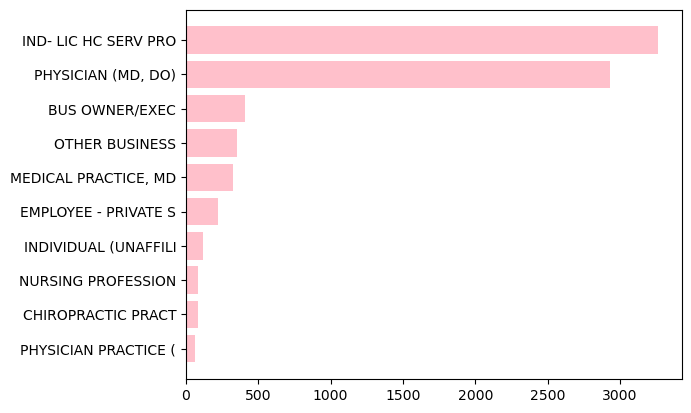

In [9]:
generals = pd.DataFrame(no_npis["general"].value_counts())

generals = generals.head(10)

generals = generals.reset_index().rename(columns={"index": "general", "count": "count"}).sort_values(by="count", ascending=True)

plt.barh(generals["general"], generals["count"], color='pink')

In [10]:
states = pd.DataFrame(no_npis["state"].value_counts())

states = states.reset_index().rename(columns={"index": "state", "count": "count"}).sort_values(by="count", ascending=True)

In [12]:
!pip install geopandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.5/32.5 MB 134.4 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.6/9.6 MB 165.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 131.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [geopandas]/4 [geopandas]


In [13]:
import geopandas as gpd

# A common source is census shapefiles via `geopandas` + `requests`
states_load = gpd.read_file("https://www2.census.gov/geo/tiger/GENZ2018/shp/cb_2018_us_state_20m.zip")

states_load = states_load[~states_load['STUSPS'].isin(["PR", "GU", "VI", "MP", "AS"])]

In [14]:
# Merge abbreviation-based df with shapefile
states_load = states_load.rename(columns={"STUSPS": "state"})  # STUSPS = state abbreviation
merged = states_load.merge(states, on="state", how="left")

# Project to equal-area CRS for cleaner plotting
merged = merged.to_crs(epsg=2163)

<Axes: >

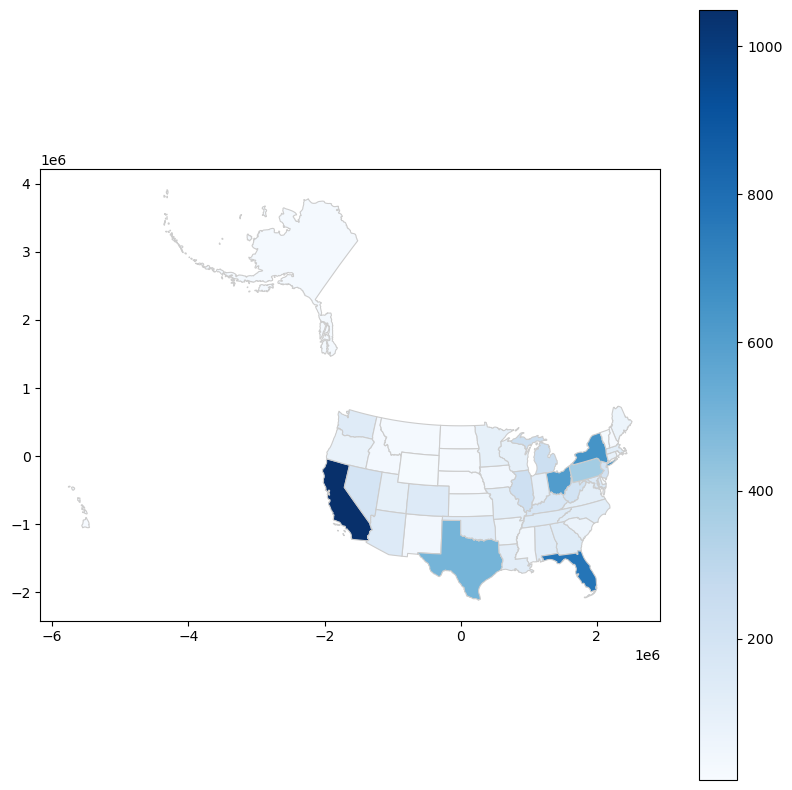

In [15]:
# Plot map
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
merged.plot(column="count", cmap="Blues", ax = ax, linewidth=0.8, edgecolor="0.8", legend=True)
